# IA-SPA: Notebook 1 -- Algorithm Overview

**Interference-Aware Submodular Placement Algorithm**  
L. Taus, R. Tsai, and J. G. Andrews (2026)

> **Paper:** "Optimal Transmitter Placement in Realistic Urban Environments"  
> Submitted to *IEEE Transactions on Wireless Communications*  
> [arXiv:2604.28153 [cs.IT]](https://arxiv.org/abs/2604.28153)

---

This notebook provides an interactive, self-contained introduction to the mathematics
and implementation of the IA-SPA without requiring a GPU or a Sionna installation.
We use a small synthetic example to illustrate:

1. The aggregated network quality functional **S(T)**
2. The concave utility function **W_bar**
3. The **marginal gain** G(x|T) = S(T union {x}) - S(T)
4. The **greedy loop** and its submodular optimality guarantee

For real-scene experiments see **Notebook 2** (San Francisco) and **Notebook 3** (Florence).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

## 1. The Concave Utility Function W_bar

The key design choice in IA-SPA is the utility function

$$\bar{W}(x) = \frac{x}{x + c}$$

This is non-negative, non-decreasing, and **concave** -- which is exactly what
Theorem II.4 requires to guarantee submodularity of S(T).

Intuitively, concavity means **diminishing returns**: improving coverage in a
well-served area contributes less utility than improving coverage in a dead zone.

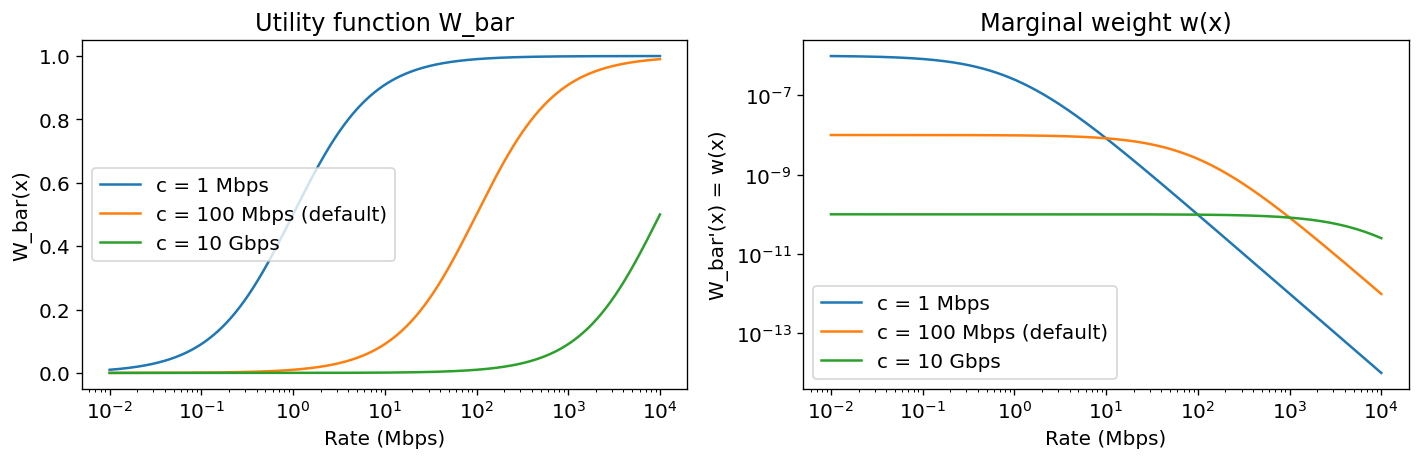

Note: w(x) is strictly decreasing -> higher weight on low-rate regions (diminishing returns).


In [2]:
def w_bar(x, c=1e8):
    """Concave utility W_bar(x) = x / (x + c)."""
    return x / (x + c)

x = np.logspace(4, 10, 500)   # rate values in bps

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for c, label in [(1e6, 'c = 1 Mbps'), (1e8, 'c = 100 Mbps (default)'), (1e10, 'c = 10 Gbps')]:
    axes[0].semilogx(x / 1e6, w_bar(x, c), label=label)
    # derivative (w)
    axes[1].loglog(x / 1e6, c / (x + c)**2, label=label)

axes[0].set(xlabel='Rate (Mbps)', ylabel='W_bar(x)', title='Utility function W_bar')
axes[0].legend()
axes[1].set(xlabel='Rate (Mbps)', ylabel="W_bar'(x) = w(x)", title='Marginal weight w(x)')
axes[1].legend()
plt.tight_layout()
plt.show()

print("Note: w(x) is strictly decreasing -> higher weight on low-rate regions (diminishing returns).")

## 2. Synthetic 2-D Environment

We create a small synthetic scenario: a 50x50 grid with three 'building' obstacles
that block signal propagation.  Each candidate transmitter position has a simple
line-of-sight coverage mask.

Grid: 50x50, Candidates: 82


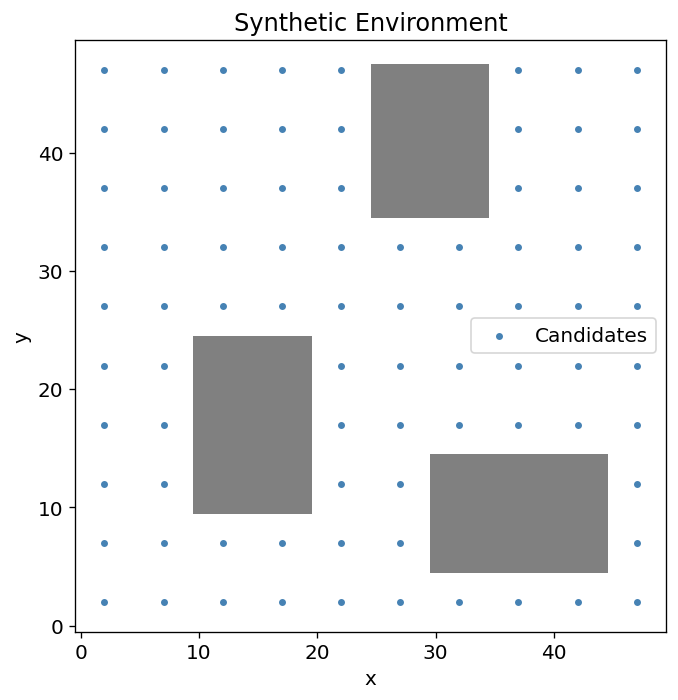

In [3]:
np.random.seed(42)
GRID = 50

# Building masks (transmitters inside or behind a building have zero path gain there)
obstacle = np.zeros((GRID, GRID), dtype=bool)
obstacle[10:20, 10:25] = True
obstacle[30:45, 5:15]  = True
obstacle[25:35, 35:48] = True

def make_path_gain(tx_ij, grid_size=GRID, decay=15.0):
    """Simple distance-based path gain with obstacle shadowing."""
    i, j = np.meshgrid(np.arange(grid_size), np.arange(grid_size), indexing='ij')
    dist = np.sqrt((i - tx_ij[0])**2 + (j - tx_ij[1])**2) + 1e-3
    pg = np.exp(-dist / decay)
    # Simple shadow: zero out cells that are 'behind' buildings
    shadow = obstacle.copy()
    pg[shadow] *= 0.05   # strong attenuation through buildings
    return pg

# Define a grid of candidate transmitter positions (every 5 cells)
candidate_positions = [(i, j) for i in range(2, GRID, 5) for j in range(2, GRID, 5)
                        if not obstacle[i, j]]
N_CANDS = len(candidate_positions)

# Pre-compute path-gain field for each candidate (simulates basis functions)
P_MAX_SCALE = 1e8   # bps at 0 distance
basis = np.array([P_MAX_SCALE * make_path_gain(pos) for pos in candidate_positions])

print(f"Grid: {GRID}x{GRID}, Candidates: {N_CANDS}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(obstacle.T, origin='lower', cmap='Greys', alpha=0.5)
ci, cj = zip(*candidate_positions)
ax.scatter(ci, cj, s=10, c='steelblue', label='Candidates')
ax.set(title='Synthetic Environment', xlabel='x', ylabel='y')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Aggregated Quality Functional S(T)

$$S(T) = \mathbb{E}_X\left[\bar{W}\left(\mathcal{P}(X, T)\right)\right]$$

where $\mathcal{P}(X, T) = \max_{t \in T} P(X, t)$ under the P_MAX model.

In [4]:
def aggregate_pmax(u, basis):
    result = np.zeros(basis.shape[1:])
    for i, w in enumerate(u):
        if w > 0:
            result = np.maximum(result, basis[i])
    return result

def S(u, basis, c=1e8):
    field = aggregate_pmax(u, basis)
    return np.mean(w_bar(field, c))

def marginal_gain(i, u, basis, c=1e8):
    v = u.copy(); v[i] += 1
    return S(v, basis, c) - S(u, basis, c)

# Verify: S({}) = 0 (only noise, no transmitters)
u_empty = np.zeros(N_CANDS)
print(f"S({{}})  = {S(u_empty, basis):.6f}   (should be ~0 with no transmitters)")

# Add the best first transmitter manually to show the gain is positive
gains_0 = [marginal_gain(i, u_empty, basis) for i in range(N_CANDS)]
best_0 = int(np.argmax(gains_0))
u_1 = u_empty.copy(); u_1[best_0] = 1
print(f"Best 1st TX at candidate #{best_0} {candidate_positions[best_0]}, G = {gains_0[best_0]:.6f}")
print(f"S(T1) = {S(u_1, basis):.6f}")

S({})  = 0.000000   (should be ~0 with no transmitters)
Best 1st TX at candidate #39 (22, 27), G = 0.187913
S(T1) = 0.187913


## 4. Running the Greedy Loop (IA-SPA)

At each step we find $x^* = \arg\max_{x} G(x|T)$ and add it to T.

Step 1: placed TX at (22, 27), S(T) = 0.187913
Step 2: placed TX at (42, 27), S(T) = 0.224164
Step 3: placed TX at (12, 7), S(T) = 0.255518
Step 4: placed TX at (7, 37), S(T) = 0.280778
Step 5: placed TX at (42, 42), S(T) = 0.294623
Step 6: placed TX at (37, 2), S(T) = 0.307988


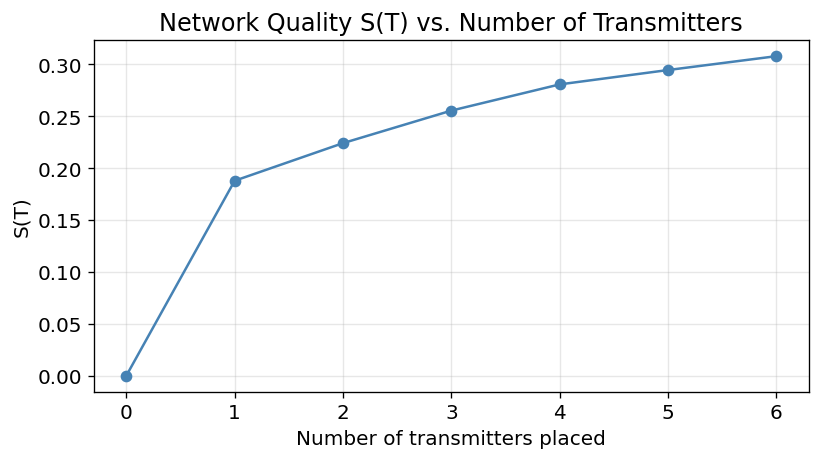

In [5]:
N_PLACE = 6   # number of transmitters to place

u = np.zeros(N_CANDS)
selected = []
s_values = [S(u, basis)]

for step in range(N_PLACE):
    gains = np.array([marginal_gain(i, u, basis) for i in range(N_CANDS)])
    best = int(np.argmax(gains))
    u[best] += 1
    selected.append(candidate_positions[best])
    s_values.append(S(u, basis))
    print(f"Step {step+1}: placed TX at {candidate_positions[best]}, S(T) = {s_values[-1]:.6f}")

# Plot S(T) over iterations
plt.figure(figsize=(7, 4))
plt.plot(range(N_PLACE + 1), s_values, 'o-', color='steelblue')
plt.xlabel('Number of transmitters placed')
plt.ylabel('S(T)')
plt.title('Network Quality S(T) vs. Number of Transmitters')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Visualising Coverage After Each Step

/tmp/ipykernel_1180055/3757715882.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


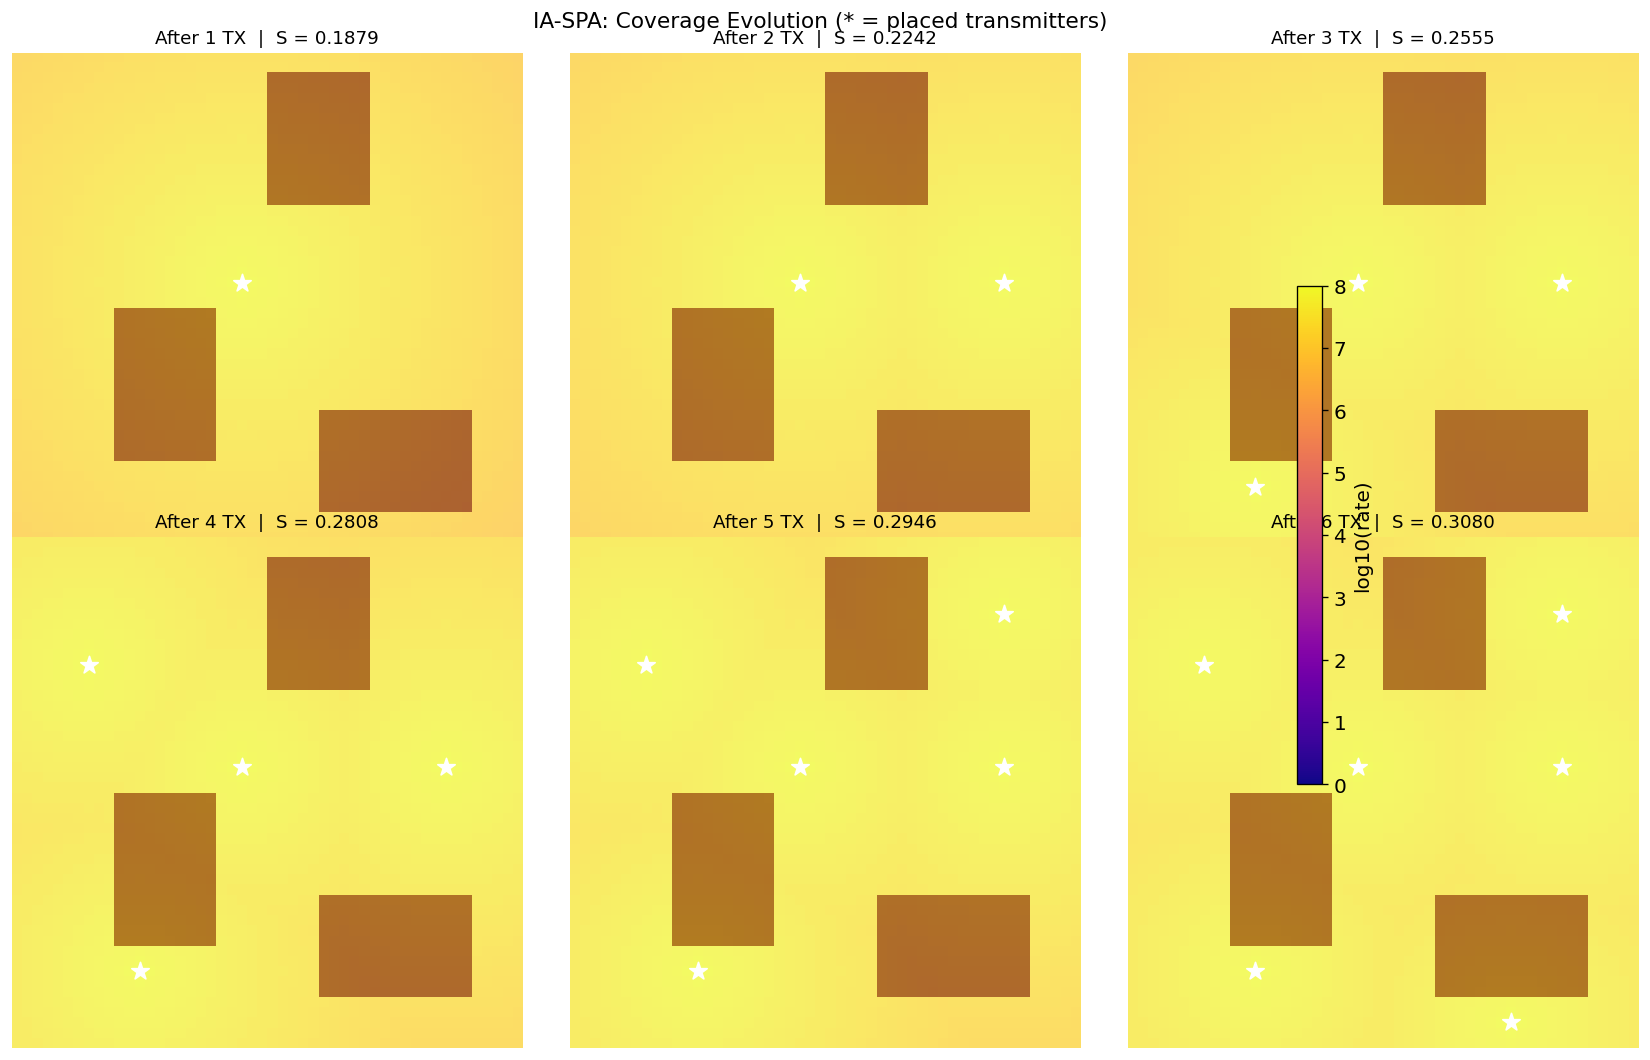

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

u_plot = np.zeros(N_CANDS)
for k, ax in enumerate(axes):
    if k < len(selected):
        ci, cj = selected[k]
        idx = candidate_positions.index((ci, cj))
        u_plot[idx] += 1

    field = aggregate_pmax(u_plot, basis)
    im = ax.imshow(np.log10(field + 1).T, origin='lower', cmap='plasma', vmin=0, vmax=8)
    ax.imshow(obstacle.T, origin='lower', cmap='Greys', alpha=0.3)

    for si, sj in selected[:k+1]:
        ax.scatter(si, sj, s=120, c='white', marker='*', zorder=5)

    ax.set_title(f'After {k+1} TX  |  S = {s_values[k+1]:.4f}', fontsize=11)
    ax.axis('off')

fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label='log10(rate)')
fig.suptitle('IA-SPA: Coverage Evolution (* = placed transmitters)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Submodularity: Diminishing Returns

Proposition III.1 states that if W_bar is concave, G(x|T1) >= G(x|T2) whenever T1 subset T2.
We can verify this empirically: the gain added by each successive transmitter should decrease.

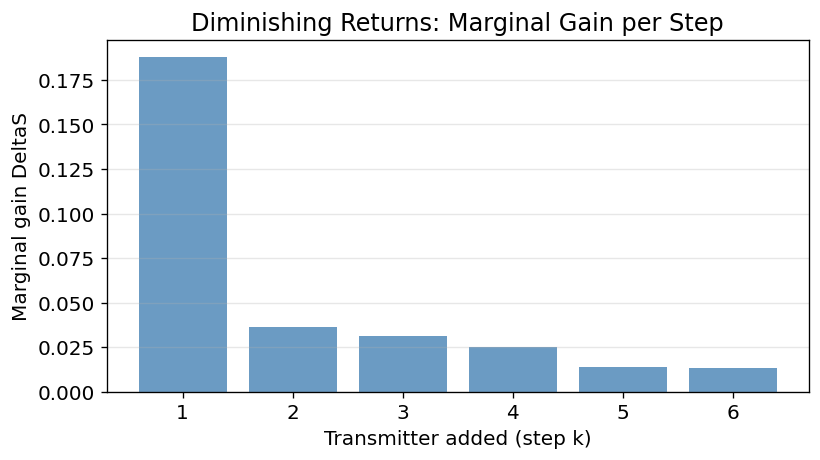

Gains are non-increasing: True  OK


In [7]:
gains_per_step = [s_values[k+1] - s_values[k] for k in range(N_PLACE)]

plt.figure(figsize=(7, 4))
plt.bar(range(1, N_PLACE+1), gains_per_step, color='steelblue', alpha=0.8)
plt.xlabel('Transmitter added (step k)')
plt.ylabel('Marginal gain DeltaS')
plt.title('Diminishing Returns: Marginal Gain per Step')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

is_diminishing = all(gains_per_step[i] >= gains_per_step[i+1] for i in range(N_PLACE-1))
print(f"Gains are non-increasing: {is_diminishing}  OK" if is_diminishing else "WARNING: not monotone")

## 7. Approximation Guarantee (Theorem III.2)

For $n = k$ and $\epsilon = 0$, the IA-SPA achieves at least

$$S(T_n) \geq \left(1 - e^{-1}\right) S(T^*_k) \approx 0.632 \cdot S(T^*_k)$$

We can estimate this bound and compare to the greedy result.

In [8]:
k = N_PLACE
n = N_PLACE
eps = 0.0

bound_factor = 1 - np.exp(-n * (1 - eps) / k)
greedy_value = s_values[-1]

# Compute a rough upper bound on S(T*_k) by running more iterations
u_upper = np.zeros(N_CANDS)
for _ in range(30):
    gains = np.array([marginal_gain(i, u_upper, basis) for i in range(N_CANDS)])
    u_upper[np.argmax(gains)] += 1
s_upper = S(u_upper, basis)

print(f"Greedy S(T_{n})     = {greedy_value:.6f}")
print(f"(1 - 1/e) guarantee = {bound_factor:.4f}")
print(f"Guaranteed lower bd = {bound_factor * s_upper:.6f}  (using S~{s_upper:.4f} as T* proxy)")
print(f"Guarantee satisfied: {greedy_value >= bound_factor * s_upper}")

Greedy S(T_6)     = 0.307988
(1 - 1/e) guarantee = 0.6321
Guaranteed lower bd = 0.234643  (using S~0.3712 as T* proxy)
Guarantee satisfied: True


## Summary

| Concept | Implementation |
|---|---|
| P_MAX aggregation | `np.maximum` over rate fields |
| Utility W_bar(x) | `x / (x + c)` -- concave, bounded |
| S(T) | `np.mean(w_bar(aggregate(u)))` |
| Marginal gain G(x\|T) | `S(T union {x}) - S(T)` |
| Greedy step | `argmax(gains)` then append |
| Guarantee | `(1 - e^{-n/k}) * S(T*_k)` |

**Next step ->** See **Notebook 2** for running this on the San Francisco Sionna scene with real ray-traced basis functions.